In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors # 【关键修改】必须引入这个库并命名为 mcolors
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Rectangle
import os

图表已成功保存至: E:\LLM+XWT\实验结果\Final_Comparison_Heatmap_NoGap.png


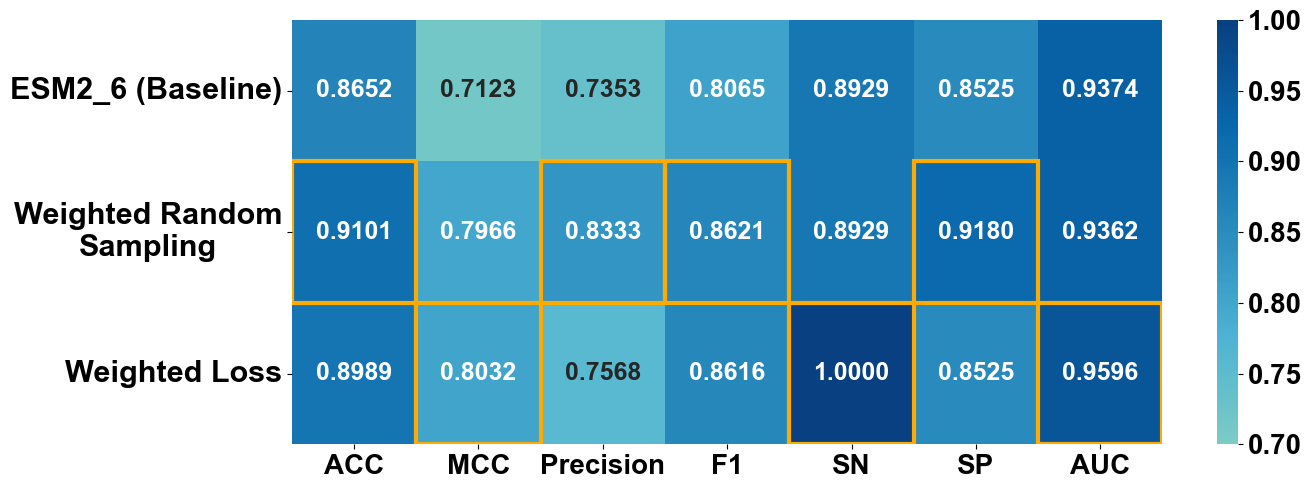

In [24]:


# -------------------------------------------------------------------------
# 1. 数据准备
# -------------------------------------------------------------------------
data = {
    "Method": ["ESM2_6 (Baseline)", "Weighted Random\nSampling", "Weighted Loss"],
    "ACC":       [0.8652, 0.9101, 0.8989],
    "MCC":       [0.7123, 0.7966, 0.8032],
    "Precision": [0.7353, 0.8333, 0.7568],
    "Recall":    [0.8929, 0.8929, 1.0000],
    "SN":        [0.8929, 0.8929, 1.0000],
    "SP":        [0.8525, 0.9180, 0.8525],
    "AUC":       [0.9374, 0.9362, 0.9596]
}

df = pd.DataFrame(data)
df.set_index("Method", inplace=True)
df["F1"] = 2 * (df["Precision"] * df["Recall"]) / (df["Precision"] + df["Recall"])
cols_order = ["ACC", "MCC", "Precision", "F1", "SN", "SP", "AUC"]
df = df[cols_order]

# -------------------------------------------------------------------------
# 2. 绘图全局设置
# -------------------------------------------------------------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

plt.figure(figsize=(14, 5))

# -------------------------------------------------------------------------
# 【重点修改】自定义颜色映射 (去除最浅的颜色)
# -------------------------------------------------------------------------
# 获取原始 GnBu 颜色带
original_cmap = plt.get_cmap("GnBu")
# 截取颜色带：从 0.15 (稍微深一点的位置) 到 1.0 (最深)
# 您可以通过调整 0.15 这个数字来改变初始颜色的深浅 (越大越深)
new_colors = original_cmap(np.linspace(0.5, 1, 256))
# 创建新的颜色对象
custom_cmap = mcolors.LinearSegmentedColormap.from_list("Truncated_GnBu", new_colors)

# -------------------------------------------------------------------------
# 3. 绘制热图
# -------------------------------------------------------------------------
ax = sns.heatmap(df, 
                 annot=True, 
                 fmt=".4f", 
                 cmap=custom_cmap,     # 使用自定义的颜色
                 cbar=True, 
                 linewidths=0,         # 【修改点1】设置为0，去除白色缝隙
                 linecolor='white',    
                 annot_kws={"size": 18, "weight": "bold", "family": "Arial"},
                 vmin=0.7, vmax=1.0)

# -------------------------------------------------------------------------
# 4. 自动画橙色框
# -------------------------------------------------------------------------
for col_index in range(df.shape[1]):
    col_values = df.iloc[:, col_index]
    max_row_index = np.argmax(col_values)
    
    rect = Rectangle((col_index, max_row_index), 1, 1, 
                     fill=False, 
                     edgecolor='#FFAA00', 
                     lw=3)
    ax.add_patch(rect)

# -------------------------------------------------------------------------
# 5. 标签美化与保存
# -------------------------------------------------------------------------
ax.xaxis.tick_bottom()
plt.xticks(fontsize=20, weight='bold', fontname='Arial')
plt.yticks(fontsize=22, rotation=0, weight='bold', fontname='Arial', multialignment='center')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)
for l in cbar.ax.yaxis.get_ticklabels():
    l.set_weight('bold')
    l.set_family('Arial')

plt.xlabel("")
plt.ylabel("")
plt.tight_layout()

# 保存设置
output_dir = r"E:\LLM+XWT\实验结果"
file_name = "Final_Comparison_Heatmap_NoGap.png"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

save_path = os.path.join(output_dir, file_name)
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"图表已成功保存至: {save_path}")

plt.show()